## 1. Information

``` py
Sumber:

Dataset yang digunakan diambil dari dataset eCommerce Google Analytics dan diambil melalui Google BigQuery. Dataset ini berisi data perilaku pengguna baru yang mengunjungi situs web e-commerce, dan target "will_buy_on_return_visit" menunjukkan apakah pengguna akan membeli pada kunjungan berikutnya.

Tujuan:

Proyek ini bertujuan untuk membangun model klasifikasi untuk memprediksi "will_buy_on_return_visit" menggunakan regresi logistik dan pohon keputusan. Kinerja model akan dievaluasi menggunakan beberapa metrik klasifikasi, termasuk presisi, fine-tuning, recall, dan ruang kurva ROC, untuk mengidentifikasi model dengan kinerja dan stabilitas terbaik.

Pernyataan Masalah:
Bagaimana kita dapat membangun model regresi logistik dan pohon keputusan untuk memprediksi "will_buy_on_return_visit"? 

Latar Belakang:  
Sebagian besar user yang mengunjungi website e-commerce tidak langsung melakukan pembelian. Tanpa analisis berbasis data, sulit mengetahui user mana yang memiliki potensi membeli. Oleh karena itu, model klasifikasi digunakan untuk membantu mengidentifikasi user yang berpeluang melakukan pembelian.
```

## 2. Query SQL

    Query untuk mendapatkan dataset_1.csv

```sql
SELECT * EXCEPT(fullVisitorId)

FROM
  # Select the features
  (SELECT
    fullVisitorId,
    IFNULL(totals.bounces, 0) AS bounces,
    IFNULL(totals.timeOnSite, 0) AS time_on_site
  FROM
    `data-to-insights.ecommerce.web_analytics`
  WHERE
    totals.newVisits = 1 # New visitor only
    AND date BETWEEN '20160801' AND '20170531') # Only the first 10 months of data will be used

JOIN
  (SELECT
    fullvisitorid,
    # Create the target
    IF(COUNTIF(totals.transactions > 0 AND totals.newVisits IS NULL) > 0, 1, 0) AS will_buy_on_return_visit
  FROM
      `data-to-insights.ecommerce.web_analytics`
  GROUP BY fullvisitorid)

USING (fullVisitorId);
```


    Query untuk mendapatkan dataset_2.csv

```sql
WITH all_visitor_stats AS (
    SELECT
      fullvisitorid,
      -- 1. Membuat label target: 1 jika pengunjung membeli di kunjungan berikutnya, 0 jika tidak.
      MAX(IF(totals.transactions >= 1, 1, 0)) AS will_buy_on_return_visit
    FROM `data-to-insights.ecommerce.web_analytics`
    GROUP BY fullvisitorid
)

SELECT * EXCEPT(unique_session_id)
FROM (
    SELECT
      CONCAT(fullvisitorid, CAST(visitId AS STRING)) AS unique_session_id,
      will_buy_on_return_visit,
      
      -- 2. Mengonversi eCommerceAction.action_type menjadi Integer
      MAX(CAST(h.eCommerceAction.action_type AS INT64)) AS latest_ecommerce_progress,

      # User behavior on the website
      IFNULL(totals.bounces, 0) AS bounces,
      IFNULL(totals.timeOnSite, 0) AS time_on_site,
      totals.pageviews,

      # Source of the visitors
      trafficSource.source,
      trafficSource.medium,
      channelGrouping,

      # Device information
      device.deviceCategory,

      # User geography
      IFNULL(geoNetwork.country, "Unknown") AS country

    FROM `data-to-insights.ecommerce.web_analytics`,
      UNNEST(hits) AS h

    JOIN all_visitor_stats USING(fullvisitorid)

    WHERE
      totals.newVisits = 1 
      -- 3. Filter rentang tanggal dari 20160801 sampai 20170531
      AND date BETWEEN '20160801' AND '20170531'

    GROUP BY
      unique_session_id,
      will_buy_on_return_visit,
      bounces,
      time_on_site,
      totals.pageviews,
      trafficSource.source,
      trafficSource.medium,
      channelGrouping,
      device.deviceCategory,
      country
)
```

## 3. Import Libraries

In [1]:
# Package yang dipake
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import kruskal, chi2_contingency
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from feature_engine.outliers import Winsorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import GridSearchCV
import joblib

## 4. Data Loading

In [2]:
data1 = pd.read_csv('dataset_1.csv')
data1

,bounces,time_on_site,will_buy_on_return_visit
0,0,54,0
1,0,167,0
2,0,184,0
3,0,141,0
4,0,715,0
...,...,...,...
623996,0,117,0
623997,0,762,0
623998,0,61,0
623999,0,75,0


In [3]:
data1.head(10)

,bounces,time_on_site,will_buy_on_return_visit
0,0,54,0
1,0,167,0
2,0,184,0
3,0,141,0
4,0,715,0
5,0,41,0
6,0,14,0
7,0,1469,0
8,0,1058,0
9,0,211,0


In [4]:
data1.tail(10)

,bounces,time_on_site,will_buy_on_return_visit
623991,0,117,0
623992,0,123,0
623993,0,54,0
623994,0,109,0
623995,0,127,0
623996,0,117,0
623997,0,762,0
623998,0,61,0
623999,0,75,0
624000,0,189,0


Insight:

    Dari hasil data diatas, didapati 10 data pertama, dan 10 data terakhir dari dataset_1.csv

In [5]:
data2 = pd.read_csv('dataset_2.csv')
data2

,will_buy_on_return_visit,latest_ecommerce_progress,bounces,time_on_site,pageviews,source,medium,channelGrouping,deviceCategory,country
0,0,0,0,705,5.0,google,organic,Organic Search,desktop,Poland
1,0,0,0,1448,5.0,google,organic,Organic Search,desktop,Germany
2,0,0,0,186,3.0,googleweblight.com,referral,Referral,mobile,India
3,0,0,0,1380,5.0,google,organic,Organic Search,desktop,Taiwan
4,0,0,0,238,5.0,google,organic,Organic Search,desktop,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
623935,0,0,0,72,3.0,youtube.com,referral,Social,desktop,Canada
623936,0,0,0,48,3.0,youtube.com,referral,Social,mobile,United States
623937,0,0,0,102,2.0,youtube.com,referral,Social,desktop,Netherlands
623938,0,0,0,40,3.0,youtube.com,referral,Social,tablet,United States


In [6]:
data2.head(10)

,will_buy_on_return_visit,latest_ecommerce_progress,bounces,time_on_site,pageviews,source,medium,channelGrouping,deviceCategory,country
0,0,0,0,705,5.0,google,organic,Organic Search,desktop,Poland
1,0,0,0,1448,5.0,google,organic,Organic Search,desktop,Germany
2,0,0,0,186,3.0,googleweblight.com,referral,Referral,mobile,India
3,0,0,0,1380,5.0,google,organic,Organic Search,desktop,Taiwan
4,0,0,0,238,5.0,google,organic,Organic Search,desktop,United Kingdom
5,0,0,0,361,5.0,(direct),(none),Direct,mobile,Indonesia
6,0,0,0,336,5.0,google,organic,Organic Search,mobile,India
7,0,0,0,1808,5.0,(direct),(none),Direct,desktop,Philippines
8,0,0,0,6,3.0,youtube.com,referral,Social,desktop,Kyrgyzstan
9,0,0,0,249,5.0,youtube.com,referral,Social,desktop,Poland


In [7]:
data2.tail(10)

,will_buy_on_return_visit,latest_ecommerce_progress,bounces,time_on_site,pageviews,source,medium,channelGrouping,deviceCategory,country
623930,0,0,0,60,3.0,youtube.com,referral,Social,desktop,United Kingdom
623931,0,0,0,1086,3.0,groups.google.com,referral,Social,desktop,United States
623932,0,0,0,112,3.0,t.co,referral,Social,desktop,Germany
623933,0,0,0,29,3.0,m.facebook.com,referral,Social,mobile,United States
623934,0,0,0,81,3.0,youtube.com,referral,Social,desktop,India
623935,0,0,0,72,3.0,youtube.com,referral,Social,desktop,Canada
623936,0,0,0,48,3.0,youtube.com,referral,Social,mobile,United States
623937,0,0,0,102,2.0,youtube.com,referral,Social,desktop,Netherlands
623938,0,0,0,40,3.0,youtube.com,referral,Social,tablet,United States
623939,0,0,0,639,3.0,facebook.com,referral,Social,desktop,France


Insight:

    Dari hasil data diatas, didapati 10 data pertama, dan 10 data terakhir dari dataset_2.csv

## 5. Exploratory Data Analysis (EDA)

### Exploratory Data Analysis (EDA) Dataset_1.csv

    Saya melakukan Exploratory Data Analysis (EDA) pada dataset_1.csv terlebih dahulu

In [8]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624001 entries, 0 to 624000
Data columns (total 3 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   bounces                   624001 non-null  int64
 1   time_on_site              624001 non-null  int64
 2   will_buy_on_return_visit  624001 non-null  int64
dtypes: int64(3)
memory usage: 14.3 MB


Insight:

    Dari hasil data diatas didapati semua data memilii tipe data integer meskipun bounces termasuk binary. Awalnya saya berniat untuk mengganti bounces menjadi kategorikal. Namun setelah menyesuaikan, dan memudahkan proses Pipeline, saya akan tetap biarkan bounces sebagai numerik (0 & 1). Dilain sisi, saya tidak perlu melakukan One-Hot Encoding lagi untuk kolom 'bounces'. Selain itu, untuk logistic regression maupun Decision tress bisa langsung memproses angka 0 dan 1 tanpa problem

In [9]:
data1.duplicated().sum()


np.int64(618597)

Insight: 

    Dari hasil data diatas menunjukan data duplicate yang sangat banyak, bisa dibilang sampai 618587. Saya tidak akan melakukan drop, sehingga saya bisa memahami kondisi asli data, termasuk keanehan di dalam dataset_1.csv

Nilai Skewness Fitur Numerik:
time_on_site    6.095895
bounces        -0.003375
dtype: float64


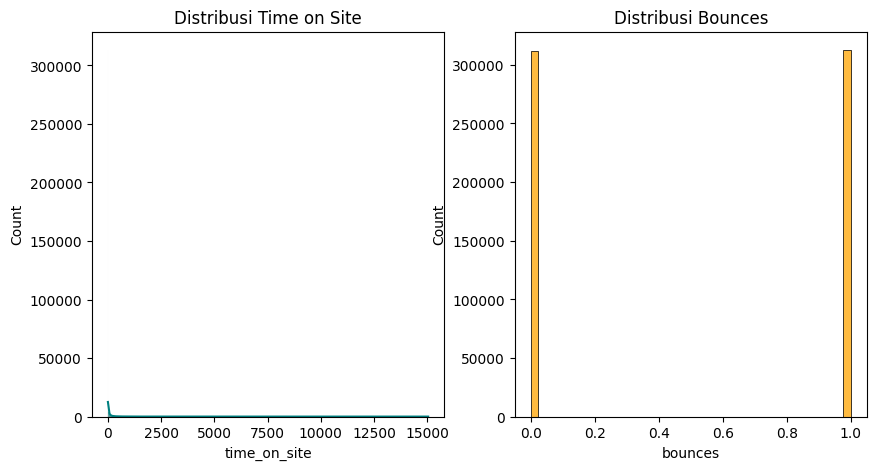

In [10]:
# Cek Skewness
print("Nilai Skewness Fitur Numerik:")
print(data1[['time_on_site', 'bounces']].skew())

# Visualisasi Histogram untuk cek kemiringan data
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(data1['time_on_site'], kde=True, color='teal')
plt.title('Distribusi Time on Site')

plt.subplot(1, 2, 2)
sns.histplot(data1['bounces'], kde=False, color='orange')
plt.title('Distribusi Bounces')
plt.show()

Insight:

    Dari hasil data diatas menunjukan bahwa time_on_site memiliki skewness positif yang bisa dibilang sangat tinggi

In [11]:
# Cek Missing Values
print("Jumlah Nilai Kosong:")
print(data1[['time_on_site', 'bounces']].isnull().sum())

# Visualisasi Missing Values (opsional jika data besar)
# sns.heatmap(data2[['time_on_site', 'bounces']].isnull(), cbar=False, yticklabels=False)

Jumlah Nilai Kosong:
time_on_site    0
bounces         0
dtype: int64


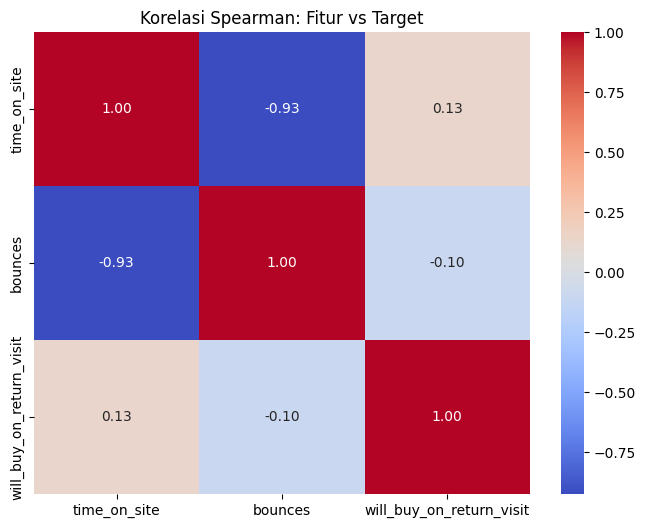

In [12]:
plt.figure(figsize=(8, 6))
correlation = data1[['time_on_site', 'bounces', 'will_buy_on_return_visit']].corr(method='spearman')
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Spearman: Fitur vs Target')
plt.show()

Insight:

      Saya menggunakan korelasi spearman, dikarenakan pada salah satu fitur bersifat biner (bounces) dan target juga biner, sehingga bisa dibilang korelasi spearman seringkali lebih cocok dibandingkan dengan pearson untuk menangkap hubungan monotonik

    Setelah itu saya ingin mengetahui seberapa pengaruh bounces terhadap target ('will_buy_on_return_visit'). Sehingga saya dapat melihat rasio konversi (pembelian) pada grup yang bounce vs tidak bounce

Probabilitas Pembelian berdasarkan Bounces:
bounces
0    0.028025
1    0.002937
Name: will_buy_on_return_visit, dtype: float64


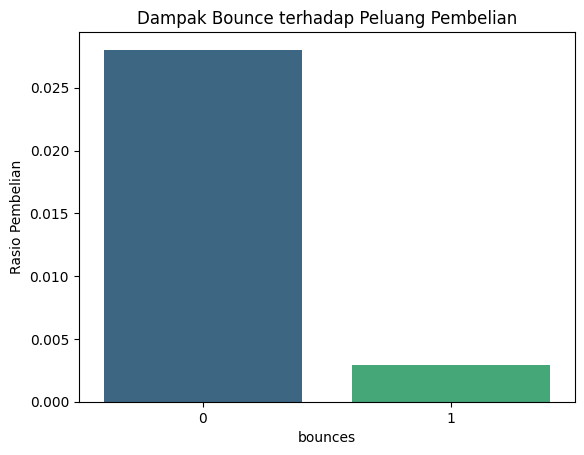

In [12]:
# inisiasi untuk perhitungan rata-rata target (probabilitas beli) untuk tiap kategori bounce
bounceImpact = data1.groupby('bounces')['will_buy_on_return_visit'].mean()

print("Probabilitas Pembelian berdasarkan Bounces:")
print(bounceImpact)

sns.barplot(x=bounceImpact.index, y=bounceImpact.values, hue=bounceImpact.index, palette='viridis',legend=False)
plt.ylabel('Rasio Pembelian')
plt.title('Dampak Bounce terhadap Peluang Pembelian')
plt.show()

Insight:

    Dari hasil analisa data diatas, asumsi saya menunjukan bahwa jika kondisi pengguna dengan kondisi 0(false) saat masuk ke situs, dan setelah itu melakukan interaksi, peluang ini bisa membuat/mentrigger pengguna untuk melakukan add chart. 
        
    Namun hal teresbut, sangat jarang dengan kondisi pengguna yang langsung melakukan pembelian hanya dalam satu kali muat halaman, kecuali jikalau kondisinya adalah halaman direct checkout yang sangat spesifik. Sedangkan untuk kondisi 1(true), kondisi dimana pengguna masuk ke situs, setelah itu pengguna hanya melihat satu halaman, dan keluar dari situ. Sehingga bisa diindikasikan bahwa pengguna tidak tertarik dengan penawaran


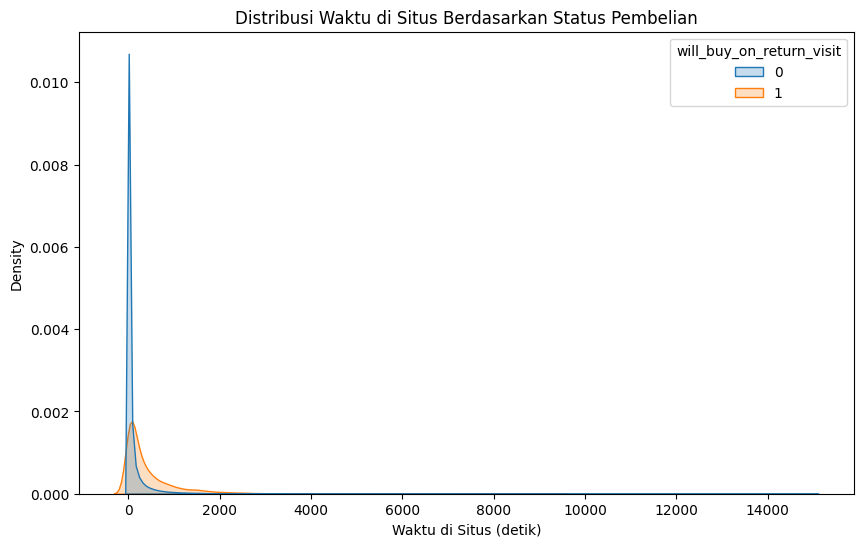

In [13]:
# Tambahkan visualisasi ini untuk melengkapi analisis Anda
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data1, x='time_on_site', hue='will_buy_on_return_visit', fill=True, common_norm=False)
plt.title('Distribusi Waktu di Situs Berdasarkan Status Pembelian')
plt.xlabel('Waktu di Situs (detik)')
plt.show()

In [14]:
data1['will_buy_on_return_visit'].value_counts(normalize=True)

will_buy_on_return_visit
0    0.98454
1    0.01546
Name: proportion, dtype: float64

Insight: 

    Dari hasil data diatas bisa dibilang bahwa total pengunjung mencapai 98.45% namun pengguna yang ketrigger untuk membeli hanya sebesar 1.54%. Sehingga bisa dibilang kondisi ini normal, dikarenakan dalam dunia e-commerce hanya sedikit yang melakukan transaksi saat itu juga (langsung) dari ribuan pengguna yang mengunjungi website

Persentase Pembelian berdasarkan status Bounce:
will_buy_on_return_visit          0         1
bounces                                      
0                         97.197519  2.802481
1                         99.706265  0.293735


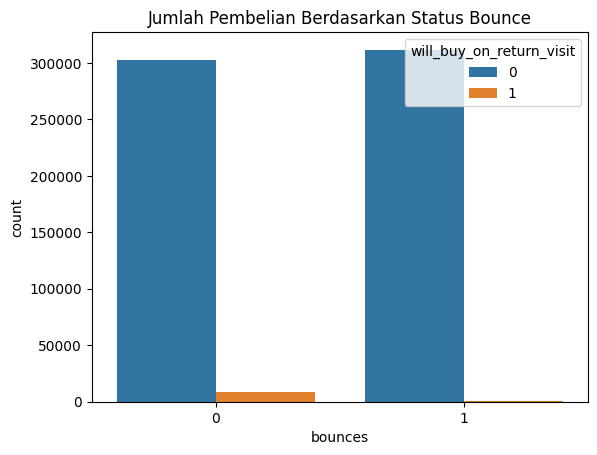

In [15]:
# Tabel kontingensi / Groupby
bounce = data1.groupby('bounces')['will_buy_on_return_visit'].value_counts(normalize=True).unstack() * 100
print("Persentase Pembelian berdasarkan status Bounce:")
print(bounce)

# Visualisasi
sns.countplot(data=data1, x='bounces', hue='will_buy_on_return_visit')
plt.title('Jumlah Pembelian Berdasarkan Status Bounce')
plt.show()

Insight:

    Dari hasil diatas didapati bahwa, sangat krusial pengaruh 'bounce' terhadap penjualan dari dataset_! yang asli. Dikarenakan bisa diasumsikan bahwa kondisi 0(tidak bounce) mengindikasikan 97,18% dari mayoritas pengguna yang tidak menjelajahi situs lebih dari 5 halaman bahkan mungkin bisa dibilang 1 halaman saja, berarti pengguna tidak akan membeli, dan sisanya hanya 2.8%, bisa dibilang pengguna yang sering beinteraksi memiliki peluang transaksi atau beli. 

    Selain itu, dilihat dari kondisi 1(bounce), mengindikasikan 99.70%, bisa dibilang hampir seluruh pengguna, dipastikan tidak akan membeli di masa yang akan mendatang, dikarenakan peluang pengguna yang ketrigger untuk membeli hanya 0.29%

    Selanjutnya saya akan melakukan expolarasi data pada dataset_2.csv 

Korelasi terhadap Target Pembelian:
will_buy_on_return_visit    1.000000
pageviews                   0.141942
time_on_site                0.128821
bounces                    -0.101666
Name: will_buy_on_return_visit, dtype: float64


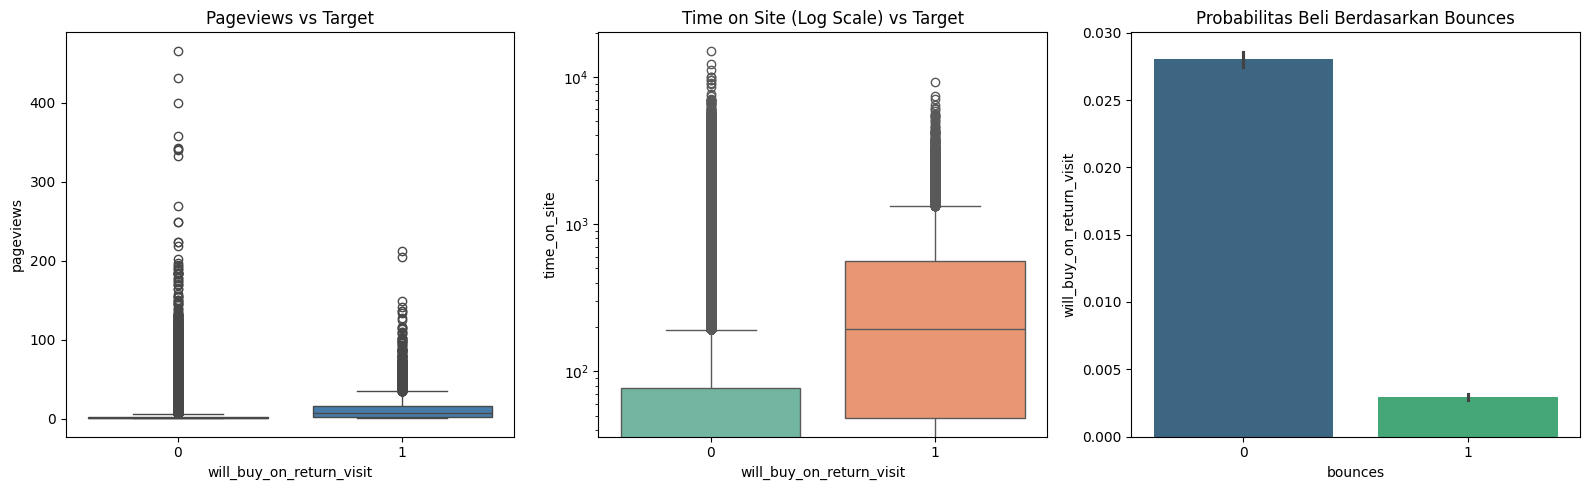

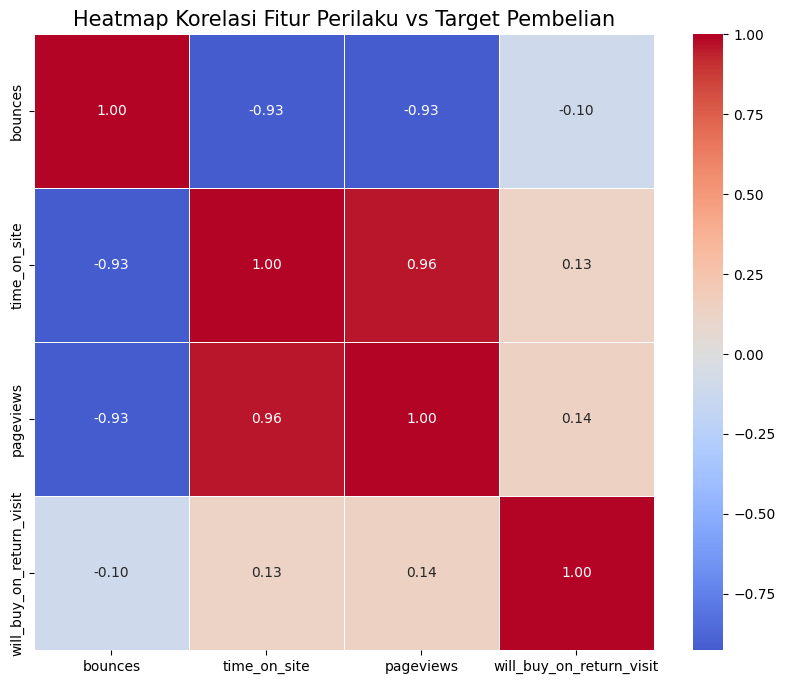

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Inisiasi menghitung Korelasi Spearman
cols = ['bounces', 'time_on_site', 'pageviews', 'will_buy_on_return_visit']
corr_matrix = data2[cols].corr(method='spearman')

print("Korelasi terhadap Target Pembelian:")
print(corr_matrix['will_buy_on_return_visit'].sort_values(ascending=False))

# Visualisasi Perbandingan Distribusi
plt.figure(figsize=(16, 5))

# Plot Pageviews
plt.subplot(1, 3, 1)
sns.boxplot(x='will_buy_on_return_visit', y='pageviews', data=data2, hue='will_buy_on_return_visit', palette='Set1', legend=False)
plt.title('Pageviews vs Target')

# Plot Time on Site
plt.subplot(1, 3, 2)
sns.boxplot(x='will_buy_on_return_visit', y='time_on_site', data=data2, hue='will_buy_on_return_visit', palette='Set2', legend=False)
plt.yscale('log') # Skala log karena data time_on_site sangat skewed
plt.title('Time on Site (Log Scale) vs Target')

# Plot Bounces
plt.subplot(1, 3, 3)
sns.barplot(x='bounces', y='will_buy_on_return_visit', data=data2, hue='bounces', palette='viridis', legend=False)
plt.title('Probabilitas Beli Berdasarkan Bounces')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,          # Menampilkan angka korelasi di dalam kotak
            cmap='coolwarm',     # Warna biru untuk negatif, merah untuk positif
            fmt='.2f',           # Dua angka di belakang koma
            center=0,            # Titik tengah warna pada angka 0
            linewidths=0.5)      # Garis pemisah antar kotak

plt.title('Heatmap Korelasi Fitur Perilaku vs Target Pembelian', fontsize=15)
plt.show()

Insight: 

    Saya menggunakan Spearman karena data bersifat skewed dan target bersifat biner. 

    Sehingga didapati bahwa pageviews, dan time_on_site memilki nilai korelasi positif. Meskipun diantara keduanya hanya dikisaran 0.2, mungkin bisa dibilang kalau diambil asumsi bahwa data tidak seimbang (imblanced), oleh karena itu angka 0.2 bisa menunjukan pengaruh yang signifikan. Sehingga bisa dikatakan jika semakin banyak halaman yang dilihat, dan semakin lama durasi kunjugannya, berarti semakin besar peluang pengguna akan membeli di masa depan.

    Namun berbanding terbalik dengan nilai bounces yang memilki korelasi negatif. Sehingga mengindikasikan bahwa jika ada pengguna yang langsung keluar situs (bounce), maka semakin kecil peluang pengguna tersebut akan kembali atau bahkan bertransaksi

Distribusi Perangkat untuk Pembeli Potensial di Canada:
deviceCategory
desktop    189
mobile      11
tablet       1
Name: count, dtype: int64


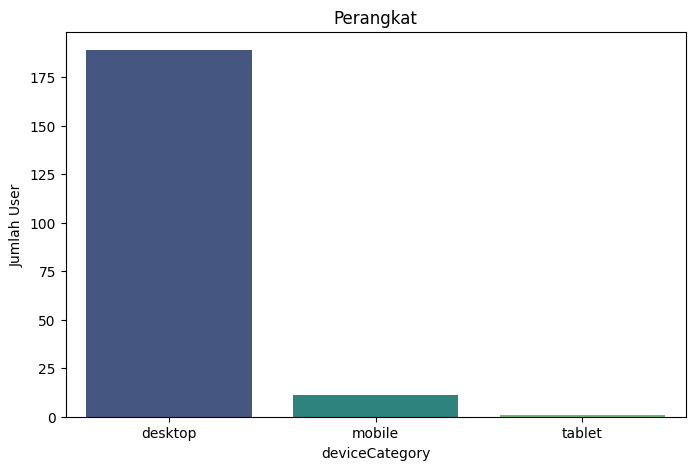


Kesimpulan: Device yang paling sering digunakan adalah desktop


In [17]:
# Inisiasi potensi pembeli diwilayah canada (will_buy_on_return_visit == 1)
canadaPotensial = data2[(data2['country'] == 'Canada') & (data2['will_buy_on_return_visit'] == 1)]

# Menghitung frekuensi jenis device
deviceCategory = canadaPotensial['deviceCategory'].value_counts()

print("Distribusi Perangkat untuk Pembeli Potensial di Canada:")
print(deviceCategory)

# Visualisasi barchart
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(x=deviceCategory.index, y=deviceCategory.values, hue=deviceCategory.index, palette='viridis', legend=False)
plt.title('Perangkat')
plt.ylabel('Jumlah User')
plt.show()

# Kondisi untuk menampilkan jawaban eksplisit
if not deviceCategory.empty:
    print(f"\nKesimpulan: Device yang paling sering digunakan adalah {deviceCategory.idxmax()}")
else:
    print("\nData tidak ditemukan untuk kriteria tersebut.")

Insight:

    Dari hasil diatas menunjukan bahwa pengguna desktop lebih banyak dibandingkan dengan pengguna mobile dan tablet

## 6. Modeling 1 - Dari dataset `dataset_1.csv`

### 6.1 Feature Engineering

In [18]:
data1.isnull().sum()

bounces                     0
time_on_site                0
will_buy_on_return_visit    0
dtype: int64

Insight:

    Dari hasil data diatas, menunjukan bahwa tidak terdapat missing value 

#### 6.1.1 Check Cardinality

In [19]:
data1.bounces.unique()

array([0, 1])

In [20]:
data1.time_on_site.unique()

array([  54,  167,  184, ..., 3466, 2934, 2821], shape=(3619,))

In [21]:
data1.will_buy_on_return_visit.unique()

array([0, 1])

Insight:

    Dari hasil diatas ditemukan bahwa fitur bounces hanya memiliki 2 nilai unique (ibaratnya data biner) dengan values 0 dan 1. Dari sini kita asumsikan kembali dari hasil yang ada di EDA bahwasannya kondisi 0, itu menunjukan terjadinya bounces, dan kondisi 1 tidak terjadi bounces 

#### 6.1.2 Split between X (Features) and y (Target)

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline 
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from feature_engine.outliers import Winsorizer
# HAPUS: from sklearn.pipeline import Pipeline
# GANTI DENGAN:
from imblearn.pipeline import Pipeline

In [23]:
# inisiasi memisahkan fitur dan target
x1 = data1.drop('will_buy_on_return_visit', axis=1)
y1 = data1['will_buy_on_return_visit']

x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y1, test_size=0.2, random_state=42, stratify=y1)
print('Train Size', x_train1.shape)
print('Test Size', x_test1.shape)

Train Size (499200, 2)
Test Size (124801, 2)


Insight:

    Dari tahap ini saya memisahkan will_buy_on_return_visit menjadi target dengan inisiasi y1

#### 6.1.3 Check Outliers

In [24]:
from sklearn.model_selection import train_test_split

#check distribution form skewness
num_cols = list(x_train1.select_dtypes(exclude='object').columns)

listItem= []

for col in num_cols:
  listItem.append([col, round(x_train1[col].skew(),1), np.where(
    (round(x_train1[col].skew(),1) <= 0.5) & (round(x_train1[col].skew(),1) >= -0.5),
    'normal',
    'skewed')])

skewness = pd.DataFrame(columns=['nama kolom', 'nilai skewness', 'distribution'], data= listItem)
skewness


,nama kolom,nilai skewness,distribution
0,bounces,-0.0,normal
1,time_on_site,6.1,skewed


Insight: 

    Dari hasil data diatas ditemukan bahwa time_on_site bisa dikatakan memiliki nilai distribusi yang cukup tinggi skewednya sampai mencapai 6.0

In [25]:
#inisasi deskriptif statistik
desc_stats = x_train1.describe().round(2).T

#inisiasi kolom
column = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range(len(skewness)):
    col = skewness.loc[row, 'nama kolom']

    if skewness.loc[row, 'distribution'] == 'skewed':
        IQR = x_train1[col].quantile(0.75) - x_train1[col].quantile(0.25)
        lower_boundary = x_train1[col].quantile(0.25) - (IQR * 3)
        upper_boundary = x_train1[col].quantile(0.75) + (IQR * 3)
    else:
        lower_boundary = x_train1[col].mean() - 3 * x_train1[col].std()
        upper_boundary = x_train1[col].mean() + 3 * x_train1[col].std()

    totout = (
        (x_train1[col] > upper_boundary).sum() / len(x_train1) * 100 +
        (x_train1[col] < lower_boundary).sum() / len(x_train1) * 100
    )

    column.append(col)
    lower_bound.append(round(lower_boundary, 2))
    upper_bound.append(round(upper_boundary, 2))
    percent_total_outlier.append(round(totout, 2))

outliers = pd.DataFrame({
    'column': column,
    'lower_boundary': lower_bound,
    'upper_boundary': upper_bound,
    'percentage_total_outlier': percent_total_outlier
}).set_index('column')

#inisiasi penggabungan tabel
summary_table = desc_stats.join(outliers)

summary_table


,count,mean,std,min,25%,50%,75%,max,lower_boundary,upper_boundary,percentage_total_outlier
bounces,499200.0,0.5,0.5,0.0,0.0,1.0,1.0,1.0,-1.0,2.0,0.00
time_on_site,499200.0,120.8,330.3,0.0,0.0,0.0,81.0,15047.0,-243.0,324.0,9.87


Insight:

    Dari hasil data diatas menunjukan bahwa persentase outlier pada time_on_site bisa dibilang tinggi, karena mencapai 9.83%, sehingga harus di lakukan capping. Untuk proses capping, saya menggunakan winsorizer, namun dibungkus didalam pipeline

In [ ]:

# Inisiasi time_on_site ke dalam numerik dan bounces ke dalam kategorik
num_features = ['time_on_site']
cat_features = ['bounces']

Insight:

    Pada tahap diatas, saya melakukan inisiasi untuk memasukkan time_on_site ke numerikal features, dan bounces ke kategorikal features

In [ ]:
# inisiasi num_pipeline untuk preprocessing pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capping', Winsorizer(capping_method='iqr', tail='right', fold=1.5)),
    ('scaler', MinMaxScaler())
])

Insight:

    Selanjutnya pada tahap diatas, saya membungkus proses handling missing value, capping, dan scaling di dalam pipeline dengan SimpleImputer untuk menangani missing value, lalu ada Winsorizer untuk menangani outliers, dan MinMaxScaler untuk mengubah skala data. Kenapa saya bungkus dengan Pipeline, karena lebih efisien, dan simpel

In [ ]:
preprocessor = ColumnTransformer([
    ('numeric', num_pipeline, num_features),
    ('categorical', SimpleImputer(strategy='most_frequent'), cat_features) 
])

Insight:

    Selanjutnya pada tahap diatas, saya mendefine hasil pipeline numerikal, dan kategorikal. Pada kategorikal, saya melakukan handling missing value dengan SimpleImputer (strategy='most_frequent')

### 6.2 Model Definition & Pipeline

    Setelah itu, saya membungkus Logistic Regression dan Decision Tree dengan pipeline, disertakan dengan SMOTE. Dikarenakan untuk mengatasi imblanced data. Awalnya, saya menggunakan class_weight = 'balanced', namun setelah mencoba memakai class_weight, ternyata bearakibat false postive yang tinggi, ibaratnya model dipaksa untuk cenderung menebak user akan membeli, tapi sebenarnya enggak beli (berdasarkan percobaan classification report yang sempat saya coba). Oleh karena itu saya menggunakan SMOTE, dikarenakan memberikan hasil variasi data, selain itu dapat mentrigger batas keputusan (decision boundary) yang lebih baik 

In [35]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

# inisiasi pipe_lorg untuk Logistic Regression dengan preprocessing, SMOTE, dan Logistic Regression
pipe_logreg = Pipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('algo', LogisticRegression(random_state=42))
])

    Setelah itu, saya membungkus Decision Tree dengan pipeline

In [36]:
from sklearn.tree import DecisionTreeClassifier

# Mampu menggabungkan Feature Engineering dan algoritma Decision Tree
pipe_dt = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('algo', DecisionTreeClassifier(random_state=42, max_depth=5))
])

### 6.3 Model Training

    Setelah itu, saya melakukaN proses train model

In [ ]:
# training logistic regression
pipe_logreg.fit(x_train1, y_train1)

# training decision tree
pipe_dt.fit(x_train1, y_train1)

,steps,"[('prep', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting.

### 6.4 Model Evaluation

    Pada tahapan ini, saya melakukan penentuan kualitas model berdasarkan ROC-AUC

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Inisiasi rocroc_auc_scores function
def roc_auc_scores(nilai):
    if nilai > 0.9: return 'Good'
    elif nilai > 0.8: return 'Fair'
    elif nilai > 0.7: return 'Decent'
    elif nilai > 0.6: return 'Not Great'
    else: return 'Poor'

# inisiasi evaluasi model
auc_logreg = roc_auc_score(y_test1, pipe_logreg.predict_proba(x_test1)[:, 1])
auc_dt = roc_auc_score(y_test1, pipe_dt.predict_proba(x_test1)[:, 1])

print(f"Logistic Regression ROC-AUC: {auc_logreg:.4f} ({roc_auc_scores(auc_logreg)})")
print(classification_report(y_test1, pipe_logreg.predict(x_test1)))

print(f"\nDecision Tree ROC-AUC: {auc_dt:.4f} ({roc_auc_scores(auc_dt)})")
print(classification_report(y_test1, pipe_dt.predict(x_test1)))

Logistic Regression ROC-AUC: 0.7779 (Decent)
              precision    recall  f1-score   support

           0       0.99      0.66      0.79    122872
           1       0.03      0.76      0.06      1929

    accuracy                           0.66    124801
   macro avg       0.51      0.71      0.43    124801
weighted avg       0.98      0.66      0.78    124801


Decision Tree ROC-AUC: 0.7796 (Decent)
              precision    recall  f1-score   support

           0       0.99      0.70      0.82    122872
           1       0.04      0.73      0.07      1929

    accuracy                           0.70    124801
   macro avg       0.52      0.72      0.45    124801
weighted avg       0.98      0.70      0.81    124801



Insight :

    Catatan Kondisi 0 dan 1:
        Kondisi 0 menunjukan bahwa pengguna tidak melakukan pembelian kembali di masa yang akan mendatang. Selain itu, mungkin pengguna ini mungkin hanya melakukan browsing pada situs, atau bisa dibilang tidak sengaja mengklik situs, lalu pergi pernah, tak pernah kembali (bisa dibilang ghosting :v) untuk bertransaksi
        
        Untuk kondisi 1, menunjukan bahwa pengguna akan melakukan pembelian pada kunjungan berikuntnya ('Will_Buy_on_Return_Visit). Sehingga ada indikasi bahwa penggunan ini menunjukan niat beli yang kuat, seperti menghabiskan waktu yang bisa dibilang sangat tertarik apa yang ditawarkan didalam situs, sehingga pengguna sampai mengeksplor di halaman situs dalam waktu yang lama, atau bahkan sampai melihat banyak halaman situs
    

    Pada hasil f1-score menunjukan bahwa dari kedua model yang saya buat mampu membedakan antara pembeli dan bukan pembeli. Namun precision kelas '1', ibaratnya ada 100 pengguna yang diprediksi model akan membeli, namun hanya 3 atau 4 orang yang 'benar-benar membeli', Sisanya salah (itungannya false positive). Selain itu recall kelas 1 menunjukan yang cukup bagus (0.73-0.76), artinya modek berhasil menangkap 75% dari total pengguna yang 'benar-benar membeli' 

    Dilain sisi, dari segi perbandingan decision tree sedikit lebih stabli karena indikator accuracy dan precionnya lebih tinggi, tanpa 
    

## 7. Modeling 2 - Dari dataset `dataset_2.csv`

### 7.1 Feature Engineering

#### 7.1.1 Check Cardinality

In [39]:
pd.set_option('display.max_colwidth', None)

cat_cols = list(data2.select_dtypes(include='object').columns)

listItem = []
for col in cat_cols:
  listItem.append([col, data2[col].nunique(), data2[col].unique()])

pd.DataFrame(columns=['nama kolom', 'jumlah nilai unique', 'nilai unique'], data=listItem)

,nama kolom,jumlah nilai unique,nilai unique
0,source,294,"[google, googleweblight.com, (direct), youtube.com, baidu, productforums.google.com, ask, sites.google.com, siliconvalley.about.com, bing, feedly.com, dfa, yahoo, so.com, facebook.com, dealspotr.com, baidu.com, arstechnica.com, reddit.com, m.facebook.com, googleux.perksplus.com, t.co, m.baidu.com, mail.google.com, docs.google.com, groups.google.com, wap.sogou.com, us.search.yahoo.com, search.xfinity.com, searchlock.com, phandroid.com, duckduckgo.com, cases.corp.google.com, csfirst.withgoogle.com, ex.fit.edu, outlook.live.com, moma.corp.google.com, plusapp.sandbox.google.com, analytics.google.com, flipboard.com, mall.googleplex.com, google.com, Partners, businessinsider.com, blog.golang.org, search.mysearch.com, sashihara.jp, qiita.com, google.co.uk, seroundtable.com, gdeals.googleplex.com, google.co.jp, l.facebook.com, quora.com, m.vk.com, plus.google.com, web.facebook.com, pinterest.com, google.fr, googleads.g.doubleclick.net, lunametrics.com, startpage.com, uk.businessinsider.com, squishable.com, away.vk.com, m.reddit.com, de.pinterest.com, trainup.withgoogle.com, online-metrics.com, gophergala.com, mg.mail.yahoo.com, connect.googleforwork.com, google.de, google.co.id, images.google, google.co.in, plus.url.google.com, desktop.google.com.ua, wheretoget.it, github.com, google.co.th, amazon.com, nordic.businessinsider.com, google.ru, ixquick.com, analytics.corp.google.com, google.com.br, h.yandex-team.ru, awics.corp.google.com, web.skype.com, m.sogou.com, au.search.yahoo.com, search.snapdo.com, int.search.tb.ask.com, uk.search.yahoo.com, sg.search.yahoo.com, myactivity.google.com, bing.com, learn.colorado.edu, crowdcompute.googleplex.com, ...]"
1,medium,7,"[organic, referral, (none), cpc, cpm, affiliate, (not set)]"
2,channelGrouping,8,"[Organic Search, Referral, Direct, Social, Paid Search, Display, Affiliates, (Other)]"
3,deviceCategory,3,"[desktop, mobile, tablet]"
4,country,218,"[Poland, Germany, India, Taiwan, United Kingdom, Indonesia, Philippines, Kyrgyzstan, Ukraine, Brazil, Egypt, Japan, United States, France, Hungary, Mexico, United Arab Emirates, Peru, Thailand, Argentina, Colombia, Netherlands, Vietnam, Italy, Denmark, Morocco, Israel, Greece, Spain, South Korea, Malaysia, China, Oman, Austria, Saudi Arabia, Russia, Portugal, Norway, Hong Kong, Tanzania, Georgia, Czechia, Belgium, Turkey, Belarus, Singapore, Ireland, Canada, Romania, Pakistan, Switzerland, Venezuela, (not set), New Zealand, Australia, Bulgaria, Bangladesh, Slovenia, Chile, Costa Rica, Kenya, Benin, Iraq, Algeria, Ecuador, Croatia, Madagascar, Côte d’Ivoire, Puerto Rico, Sweden, South Africa, Congo - Kinshasa, Kazakhstan, Jordan, Serbia, Nigeria, New Caledonia, Bosnia & Herzegovina, Uzbekistan, Kuwait, Guadeloupe, Honduras, Laos, Zambia, Sri Lanka, Burkina Faso, Bahamas, Panama, Lithuania, Sudan, Moldova, Palestine, Azerbaijan, Cambodia, Estonia, Slovakia, El Salvador, St. Lucia, Dominican Republic, Bolivia, ...]"


Insight:

    Setelah di cek cardinality, dihasilkan bahwa source, dan country memilki nilai cardinality yang bisa dibilang jumlah uniquenya diatas 200. Dikarenakan pada dasarnya, jika terdapat kolom diatas 10, harus di handling. Oleh karena itu, ditahap selanjutnya saya akan melakukan grouping untuk membedakan kolom yang variatif & banyak outlier, kolom yang variansnya rendah, dan fitur kategorik

#### 7.1.2 Split between X (Features) and y (Target)

In [ ]:
# Iniasiasi drop Kolom & Grouping Country
x2 = data2.drop(['will_buy_on_return_visit', 'source', 'medium'], axis=1)
y2 = data2['will_buy_on_return_visit']

Insight:

    Pada tahap diatas, saya melakukan drop kolom source, den medium bersamaan dengan will_buy_on_return_visit. Setelah itu will_buy_on_return_visit dimasukkan ke target (y)

### 7.1.3 Spliting data

In [ ]:
# Inisiasi to_contonent
def to_continent(country):
    if country in ['United States', 'Canada', 'Mexico']: return 'North America'
    elif country in ['Indonesia', 'India', 'Japan', 'Thailand', 'Malaysia']: return 'Asia'
    elif country in ['United Kingdom', 'France', 'Germany', 'Italy']: return 'Europe'
    else: return 'Others'

Inisight:

    Pada tahap diatas, saya melakukan fungsi Grouping Country ke Continent dengan membaginya menjadi beberapa benua. Namun jikalau terdapat nama negara yang tidak saya definisikan, akan dimasukkan ke 'Others'

In [42]:
x2['continent'] = x2['country'].apply(to_continent)
x2.drop('country', axis=1, inplace=True)

Insight :

    Pada tahap ini, saya mengeksekusi dari proses sebelumnya dengan membagikan beberapa country ke continent, dan setelah itu saya menghapus 'country'

In [43]:
#inisiasi Split Data
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, test_size=0.2, random_state=42, stratify=y2)

Insight:

    Selanjutnya, pada tahap ini saya melakukan split data, antara x_train2, x_test2, y_train2, dan y_test2. Namun disini saya memberikan parameter stratify = y2, dikarekana datanya imblanced yang menunjukan bahwa pembeli/pengguna situs jauh lebih sedikit dibandingkan non pembeli/pengguna, ibaratnya stratify = y2 memastikan bahwa proporsi target (label 0 dan 1) di data trainig, dan data test tetap sama atau bisa dibilang identik dengan data aslinya

In [ ]:
# Pipeline Preprocessing

# Inisiasi kolom yang variatif & banyak outlier (Butuh Winsorizer)
num_cols_skewed = ['time_on_site', 'pageviews']

# inisiasi kolom yang variasinya rendah/biner (Cukup Scaling)
num_cols_low_var = ['latest_ecommerce_progress']

# Fitur Kategorik: channelGrouping, deviceCategory, continent, bounces
cat_cols = ['channelGrouping', 'deviceCategory', 'continent', 'bounces']

In [ ]:
# print untuk ringkasan statistik
print(data2[num_cols_skewed].describe())

# iprint untuk angka skewness secara spesifik
print("\nNilai Skewness:")
print(data2[num_cols_skewed].skew())

In [ ]:
# Cek sebaran nilai unik
print("Sebaran Nilai latest_ecommerce_progress:")
print(data2['num_cols_low_var '].value_counts().sort_index())

# Cek persentase kemunculan
print("\nPersentase:")
print(data2['num_cols_low_var '].value_counts(normalize=True).sort_index() * 100)

Insight:

    Pada tahap ini saya memisahkan fitur numerik seperti time_on_site, pageviews, latest_ecommerce_progress ke beberapa kolom. Dikarenakan dari masing-masing kolom tersebut memiliki karakteristik data yang berbeda. Dimulai dari time_on_site dan pageviews yang memiliki outlier, sehingga menyebabkan skewed. 
    
    Dilain sisi pada kolom latest_ecommerce_progress hanya cukup di scaling, karena pada kolom ini  variansnnya rendah atau bisa di bilang biner

    Selanjutnya saya akan melakukan imputer, capping, scaler yang dibungkus didalam Pipeline terhadap fitur / kolom yang sudah saya grouping sebelumnya 

In [63]:
skewed_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capping', Winsorizer(capping_method='iqr', tail='right', fold=1.5)),
    ('scaler', MinMaxScaler())
])

Insight:

    Dari tahap ini, saya mendefine imputer menggunakan simpleimputer, capping menggunakan winsorizer, dan scaling menggunakan minmaxscaler. Untuk skewed_pipeline akan di define pada columnTransformer  

In [64]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

Insight: 

    Dari tahap ini, saya melakukan imputer dengan simpleimputer untuk menangani data kosong pada fitur kategorikal dengan menggunakan strategy='most_frequent', dikarenakan 'most_frequent' mampu mencari nilai yang paling sering muncul dalam satu kolom. Dilain sisi, data katagori seperti continent, dan jenis device tidak akan bisa dihitung nilai meannya (rata"), oleh karena itu 'most_frequent' akan mengisi dengan nilai yang paling sering muncul atau bisa dibilang populer.

    Selain itu, saya menggunaan onehotencoder untuk mengubah teks menjadi angka 0 ataupun 1, supaya nantinya bisa dibaca oleh algoritma decisition tree dan logistic regression. Untuk cat_pipeline akan di define pada columnTransformer  

    

In [65]:
low_var_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

Insight: 

    Dari tahapan ini, dikarenakan kolom / fitur 'latest_ecommerce_progress' memiliki varians yang rendah, jadi saya hanya melakukan simpleimputer untuk mengisi missing value dengan nilai median, dan scaling menggunakan minmaxscaler. Untuk low_var_pipeline akan di define pada columnTransformer  


In [66]:
preprocessor2 = ColumnTransformer([
   ('num_skewed', skewed_pipeline, num_cols_skewed),
    ('num_low_var', low_var_pipeline, num_cols_low_var),
    ('cat', cat_pipeline, cat_cols)
])

Insight:

    Dari semua tahapan kolom grouping yang sudah di proses secara masing-masing dari setiap kolom grouping seperti handling missing value, capping, dan scaling serta onehotencoder (khusus kolom grouping kategorikal) yang dibungkus ke dalam pipeline. Saya melakukan ColumnTransformer untuk mendefine proses handling pada semua kolom grouping useperti 'num_skewed', 'num'_low_var', dan 'cat untuk nanti bisa di gunakan pada tahapan mdoel definition

## 7.2 Model Definition

    Pada tahapan ini, saya akan mendefine algoritma apa saja yang akan dipakai. Algoritma yang dipakai adalah Logistic Regression, dan Decision Tree

In [ ]:
'''
inisiasi pipe_lr2 dibungkus Pipeline (Feature Engineering + Algorithm Logistic Regression)
'''
pipe_lr2 = ImbPipeline([
    ('prep', preprocessor2),
    ('smote', SMOTE(random_state=42)),
    ('algo', LogisticRegression(random_state=42))
])

Insight:

    Pada tahapan ini, saya mendefinisikan feature engineering untuk algoritma Logistic Regression dengan memanggil preprocessor2 ('prep'), yang pada proses sebelumnya sudah di define, dan dilakukan column Transformer. Selain itu, saya menggunakan SMOTH ('smote') untuk mengatasi imblanced data, dan inisiasi ('algo') dengan memanggil package LogisticRegression

    Setelah itu, saya bungkus dengan Pipeline dengan inisiasi pipe_lr2, untuk nanti bisa dipanggil pada tahap model training

In [ ]:
'''
inisiasi pipe_lr2 dibungkus Pipeline (Feature Engineering + Algorithm Decision Tree)
'''
pipe_dt2 = ImbPipeline([
    ('prep', preprocessor2),
    ('smote', SMOTE(random_state=42)),
    ('algo', DecisionTreeClassifier(random_state=42, max_depth=5))
])

Insight:

    Pada tahapan ini, saya mendefinisikan feature engineering untuk algoritma Decision Tree dengan memanggil preprocessor2 ('prep'), yang pada proses sebelumnya sudah di define, dan dilakukan column Transformer. Selain itu, saya menggunakan SMOTH ('smote') untuk mengatasi imblanced data, dan inisiasi ('algo') dengan memanggil package DecisionTreeClassifier

    Setelah itu, saya bungkus dengan Pipeline dengan inisiasi pipe_lr2, untuk nanti bisa dipanggil pada tahap model training 

## 7.3 Model Training

    Pada tahapan ini saya melakukan train data, dengan menggunakan tuning GridSearch pada Algoritma decision tree, yang bertujuan untuk mengoptimalkan performa dengan menguji kombinasi max_depth, dan criterion melalui cross validation, sehingga dapat mengurangi resiko overfitting, dan pastinya memastikan model supaya melakukan generalisasi yang proper. khususnya dalam memaksimalkan hasil nilai ROC-AUC yang di proses pada tahap selanjutnya (model evaluation)

In [69]:
# Baseline Training
pipe_lr2.fit(x_train2, y_train2)
pipe_dt2.fit(x_train2, y_train2)

# Contoh Tuning pada Decision Tree
param_dt = {'algo__max_depth': [3, 5, 7], 'algo__criterion': ['gini', 'entropy']}
grid_dt2 = GridSearchCV(pipe_dt2, param_dt, cv=3, scoring='roc_auc').fit(x_train2, y_train2)
best_dt2 = grid_dt2.best_estimator_

## 7.4 Model Evaluation

    Pada tahap ini saya melakukan evaluation dengan menggunakan score ROC-AUC

=== EVALUASI LOGISTIC REGRESSION ===
ROC-AUC Train: 0.9369
ROC-AUC Test : 0.9369
              precision    recall  f1-score   support

           0       1.00      0.84      0.91    122859
           1       0.08      0.90      0.15      1929

    accuracy                           0.84    124788
   macro avg       0.54      0.87      0.53    124788
weighted avg       0.98      0.84      0.90    124788


=== EVALUASI DECISION TREE ===
ROC-AUC Train: 0.9318
ROC-AUC Test : 0.9303
              precision    recall  f1-score   support

           0       1.00      0.84      0.91    122859
           1       0.08      0.90      0.15      1929

    accuracy                           0.84    124788
   macro avg       0.54      0.87      0.53    124788
weighted avg       0.98      0.84      0.90    124788



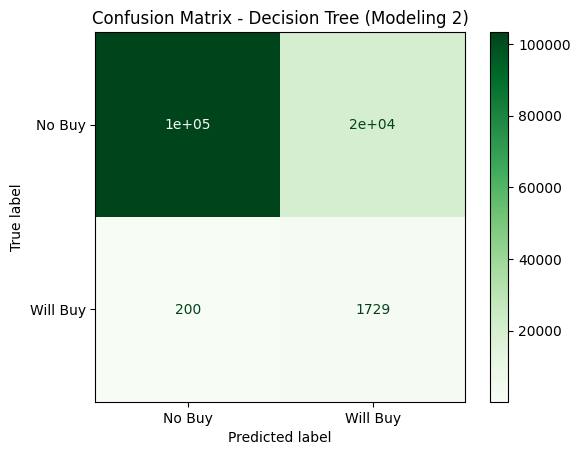

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# insiasi menampikan hasil Logistic Regression
auc_train_lr = roc_auc_score(y_train2, pipe_lr2.predict_proba(x_train2)[:, 1])
auc_test_lr = roc_auc_score(y_test2, pipe_lr2.predict_proba(x_test2)[:, 1])

print("=== EVALUASI LOGISTIC REGRESSION ===")
print(f"ROC-AUC Train: {auc_train_lr:.4f}")
print(f"ROC-AUC Test : {auc_test_lr:.4f}")
print(classification_report(y_test2, pipe_lr2.predict(x_test2)))

# inisiasi menampilkan hasil Decision Tree
auc_train_dt = roc_auc_score(y_train2, pipe_dt2.predict_proba(x_train2)[:, 1])
auc_test_dt = roc_auc_score(y_test2, pipe_dt2.predict_proba(x_test2)[:, 1])

print("\n=== EVALUASI DECISION TREE ===")
print(f"ROC-AUC Train: {auc_train_dt:.4f}")
print(f"ROC-AUC Test : {auc_test_dt:.4f}")
print(classification_report(y_test2, pipe_dt2.predict(x_test2)))

# Visualisasi Confusion Matrix (Model Terbaik)
# inisiasi jikalau algoritma Decision Tree memberikan skor lebih stabil
cm = confusion_matrix(y_test2, pipe_dt2.predict(x_test2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Buy', 'Will Buy'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Decision Tree (Modeling 2)')
plt.show()

Insight:

    Dari hasil pengujian score ROC-AUC, menunjukan bahwa:
    
    Pada logistic regression (0.9369) sedikit lebih tinggi dibandingkan decision tree (0.9303). Ini membuktikan bahwa model yang sudah saya buat, dapat membedakan antara pengguna yang ibaratnya yang hanya mengeksplor (label 0), dan pengguna yang niat beli di situs (label 1). Sehingga dapat dilihat selisih pada train dan test pada logistic regression, tidak ada selisih, oleh karena itu model yang saya buat sangat stabil, dan memiliki generalisasi yang bisa dibilang perfect. Selain itu didapati nilai recall yang tinggi (0.90), ibaratnya terdapat 100 pengguna yang akan membeli, namun model yang saya buat mampu menangkap 90 pengguna. Sehingga model saya bersifat sensitif terhadap calon pembeli di dalam situs. Namun precisionnya rendah (0.08), yang artinya dari orang yang ditebak model sebagai "pembeli", hanya 8% yang benar-benar membeli. Sisanya (92%) adalah False Positive (orang yang dikira beli, padahal enggak mau beli)

    Pada decision tree, sedikit penurunan pada model ini hanya sedikit menjadi 0.9303. Recall memiliki 0.90, yang berarti model yang saya buat berhasil mendeteksi 90% pengguna yang serius untuk membeli, meskipun precisionnya rendah (0.08) yang bisa mengakibatkan banyak salah mendefine ibaratnya pengguna yang tidak beli namun dikiranya malah beli

    Dari kedua algoritma menunjukan bahwa nilai f1-score (0.15) yang rendah pada kelas 1 (pembeli), disebabkan oleh rendahnya precision (0.08). Namun, dikarenakan ROC-AUC sangat tinggi (0.93), ini membuktikan model yang saya buat memiliki kemampuan pemisahan yang bisa dibilang sangat baik, hanya saja "ambang batas" (threshold)




    Sehingga saya memilih Decision Tree untuk dilanjutkan ke proses hyper parameter tuning

## 8. Modeling 3 - Hyperparameter Tuning

## 8.1 Hyperparameter Tuning - Training

    Pada tahap ini saya melakukan hyper parameter pada algoritma decision tree

In [ ]:
from sklearn.model_selection import GridSearchCV

# Menentukan Parameter yang akan diuji
# inisiasi param_grid dikarenakan menggunakan Pipeline, penamaan parameter harus diawali 'algo__'
param_grid = {
    'algo__max_depth': [3, 5, 7, 10],
    'algo__min_samples_split': [2, 5, 10],
    'algo__criterion': ['gini', 'entropy'],
    'algo__class_weight': ['balanced', None] # Eksperimen tambahan selain SMOTE
}

Insight: 

    Pada tahap ini saya memanggil algo_ yang sudah di define, dengan memberikan angka parameter, dan nantinya grid search akan mencoba satu-satu

In [ ]:
# Inisialisasi GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe_dt2, 
    param_grid=param_grid, 
    cv=5, #Cross Validation 5-Fold
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)

Insight:

    Pada tahap ini saya menggunakan scoring 'roc_auc' supaya konsisten dengan evaluasi pada tahapan sebelumnya. Didukung dengan 'cv=5' yang membuat model akan dilatih sebanyak 5 kali untuk setiap kombinasi. Sehingga pada pada setiap kali latihan, 4 bagian digunakan untuk belajar dan 1 bagian digunakan untuk tes (validasi)

In [ ]:
# inisiasi Training / Fitting
grid_search.fit(x_train2, y_train2)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'algo__class_weight': ['balanced', None], 'algo__criterion': ['gini', 'entropy'], 'algo__max_depth': [3, 5, ...], 'algo__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [ ]:
# Inisiasi untuk mendapatkan Model Terbaik
best_tuned_model = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Training ROC-AUC: {grid_search.best_score_:.4f}")

Best Parameters: {'algo__class_weight': 'balanced', 'algo__criterion': 'entropy', 'algo__max_depth': 7, 'algo__min_samples_split': 2}
Best Training ROC-AUC: 0.9360


Insight: 

    Setelah di train didapati best training score ROC-AUC sebesar 0.9360. Sehingga bisa dibilang selisihnya sangat tipis

### 8.2 Hyperparameter Tuning - Evaluation

In [78]:
# Prediksi dengan model baru (Tuned)
y_pred_tuned = best_tuned_model.predict(x_test2)
y_proba_tuned = best_tuned_model.predict_proba(x_test2)[:, 1]

# Perhitungan Score
auc_before = auc_test_dt # Dari Modeling 2
auc_after = roc_auc_score(y_test2, y_proba_tuned)

print("=== Comparison: Before vs After Tuning ===")
print(f"ROC-AUC Before Tuning: {auc_before:.4f}")
print(f"ROC-AUC After Tuning : {auc_after:.4f}")

# Visualisasi Classification Report Model Terakhir
print("\nFinal Classification Report (Tuned Model):")
print(classification_report(y_test2, y_pred_tuned))

=== Comparison: Before vs After Tuning ===
ROC-AUC Before Tuning: 0.9303
ROC-AUC After Tuning : 0.9371

Final Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       1.00      0.85      0.92    122859
           1       0.09      0.89      0.16      1929

    accuracy                           0.85    124788
   macro avg       0.54      0.87      0.54    124788
weighted avg       0.98      0.85      0.91    124788



Insight:

    Dari hasil data diatas menunjukan bahwa accuracynya 85%, selain itu pada metric recall menunjukan bahwa model berhasil mengindentifikasi 89% pengguna yang akan melakukan pembelian. Namun metric precisionnya hanya 9%, menunjukan bahwa banyak pembeli yang diprediksi tetapi faktanya bukan pembeli

## 9. Model Saving

    Saya membuat model saving dari tahapan modeling 1, modeling 2, dan modeling 3

In [ ]:
import joblib

#SAVING MODELLING 1
# kondisi jika auc_logreg lebih besar atau sama dengan auc_dt, lalu disimpan model Logistic Regression
if auc_logreg >= auc_dt:
    joblib.dump(pipe_logreg, 'model_modeling_1.pkl')
    print("\n Model Logistic Regression berhasil disimpan.")
else:
    joblib.dump(pipe_dt, 'model_modeling_1.pkl')
    print("\n Model Decision Tree berhasil disimpan.")
    
#SAVING MODELLING 2
# Memilih model terbaik berdasarkan skor AUC Test tertinggi
best_model = pipe_dt2 if auc_test_dt >= auc_test_lr else pipe_lr2

# Simpan model beserta seluruh pipeline preprocessing-nya
joblib.dump(best_model, 'best_ecommerce_model_v2.pkl')

print(f"Model terbaik berhasil disimpan!")

#SAVING MODELLING 3
# Menyimpan model final hasil tuning
joblib.dump(best_tuned_model, 'final_ecommerce_model_tuned.pkl')

print("Model Final (Tuned) berhasil disimpan: final_ecommerce_model_tuned.pkl")

Model Final (Tuned) berhasil disimpan: final_ecommerce_model_tuned.pkl


## 10. Kesimpulan

Berdasarkan korelasi Spearman, pageviews dan time_on_site adalah prediktor terkuat. Hal ini membuktikan bahwa strategi content engagement sangat berpengaruh pada konversi. 

Selain itu Model Decision Tree menunjukkan performa yang (ROC-AUC 0.93) tanpa gejala overfitting, menjadikannya saya memilihnya untuk sistem produksi. 

Dengan indikator recall mencapai 0.90, tim marketing dapat mendeteksi 90% calon pembeli potensial untuk diberikan intervensi khusus (seperti diskon ongkir), meskipun harus menghadapi False Positive sebesar 8-10% akibat data yang sangat tidak seimbang.

Selain itu, Didapati bahwa hasil dari Decision Tree menjadi lebih baik setelah di proses hyper paramating, dan membuat score nilai AUCnya mencapai 0.9371. Sehingga bisa lebih baik hasilnya dibandingkan decision tree. Faktor penggunaan teknik SMOTE terbukti efektif, dan model mampu mencapai recall sebesar 90%, sehinga sistem berhasil mengidentifikasi 90% dari pembeli asli di masa depan. Oleh karena itu, secara keseluruhan proyek ini berhasil membangun solusi prediktif yang tangguh dan proper untuk mengidentifikasi niat beli pengguna, dengan indikator akan membeli atau tidak membeli